# Week 11: DBSCAN and Hierarchical Agglomerative Clustering

This notebook applies density-based spatial clustering of applications with noise (DBSCAN) and hierarchical agglomerative clustering (HAC) to the Diabetes Health Indicators and Alzheimer's disease datasets.

The analysis will examine how DBSCAN identifies dense groups and noise using epsilon and minimum-point parameters, how different linkage methods affect hierarchical clustering, and how dendrograms can be used to interpret cluster structure.

Because both DBSCAN and HAC rely on distances between observations, the predictor variables will be standardized before clustering. The known diabetes and Alzheimer's diagnosis variables will not be used to create the clusters, but they can later be compared with the resulting groups to help interpret whether the clusters correspond to meaningful patient differences.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [3]:
df_diabetes = pd.read_csv(
    "diabetes_012_health_indicators_BRFSS2015.csv"
)

df_alzheimers = pd.read_csv(
    "alzheimers_disease_data.csv"
)

df_alzheimers = df_alzheimers.drop(
    columns=["DoctorInCharge"]
)

print("Diabetes dataset shape:", df_diabetes.shape)
print("Alzheimer's dataset shape:", df_alzheimers.shape)

Diabetes dataset shape: (253680, 22)
Alzheimer's dataset shape: (2149, 34)


In [4]:
X_diabetes = df_diabetes.drop(columns=["Diabetes_012"])
y_diabetes = df_diabetes["Diabetes_012"]

X_alzheimers = df_alzheimers.drop(
    columns=["Diagnosis", "PatientID"]
)
y_alzheimers = df_alzheimers["Diagnosis"]

print("Diabetes clustering features:", X_diabetes.shape)
print("Alzheimer's clustering features:", X_alzheimers.shape)

Diabetes clustering features: (253680, 21)
Alzheimer's clustering features: (2149, 32)


## Data Preparation

The diagnosis variables are excluded from the clustering features because DBSCAN and HAC are unsupervised methods. The purpose is to determine whether natural patient groups can be identified without using the known outcome to create them.

`PatientID` is also removed from the Alzheimer's predictors because it is an identifier rather than a meaningful patient characteristic. Including it in a distance-based method could create artificial differences between observations.

The features will be standardized before clustering because DBSCAN and HAC depend on distances between observations. Without scaling, variables measured on larger numerical ranges could have a disproportionate influence on the resulting clusters.

In [5]:
scaler_diabetes = StandardScaler()
X_diabetes_scaled = scaler_diabetes.fit_transform(X_diabetes)

scaler_alzheimers = StandardScaler()
X_alzheimers_scaled = scaler_alzheimers.fit_transform(X_alzheimers)

print("Diabetes scaled shape:", X_diabetes_scaled.shape)
print("Alzheimer's scaled shape:", X_alzheimers_scaled.shape)

Diabetes scaled shape: (253680, 21)
Alzheimer's scaled shape: (2149, 32)


In [6]:
diabetes_sample = X_diabetes.sample(n=5000, random_state=42)
diabetes_sample_y = y_diabetes.loc[diabetes_sample.index]

alzheimers_sample = X_alzheimers.copy()
alzheimers_sample_y = y_alzheimers.copy()

scaler_diabetes_sample = StandardScaler()
X_diabetes_sample_scaled = scaler_diabetes_sample.fit_transform(diabetes_sample)

scaler_alzheimers_sample = StandardScaler()
X_alzheimers_sample_scaled = scaler_alzheimers_sample.fit_transform(alzheimers_sample)

print("Diabetes clustering sample:", X_diabetes_sample_scaled.shape)
print("Alzheimer's clustering sample:", X_alzheimers_sample_scaled.shape)

Diabetes clustering sample: (5000, 21)
Alzheimer's clustering sample: (2149, 32)


## Clustering Sample

The diabetes dataset contains more than 250,000 observations. Hierarchical clustering becomes computationally expensive on datasets of this size because it repeatedly compares distances between observations and clusters. A reproducible random sample of 5,000 diabetes observations is therefore used for the Week 11 clustering analysis.

The Alzheimer's dataset contains only 2,149 observations, so the full dataset can be retained.

The diagnosis variables remain separate from the clustering features. They will only be used after clustering to help interpret whether the discovered groups correspond to meaningful differences in disease status.

In [7]:
def summarize_dbscan(X, eps_values, min_samples_values):
    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )
            
            labels = model.fit_predict(X)

            clusters = set(labels)
            n_clusters = len(clusters) - (1 if -1 in clusters else 0)
            n_noise = np.sum(labels == -1)
            noise_pct = n_noise / len(labels) * 100

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "clusters": n_clusters,
                "noise_points": n_noise,
                "noise_percent": noise_pct
            })

    return pd.DataFrame(results)

In [8]:
eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 20]

diabetes_dbscan_results = summarize_dbscan(
    X_diabetes_sample_scaled,
    eps_values,
    min_samples_values
)

alzheimers_dbscan_results = summarize_dbscan(
    X_alzheimers_sample_scaled,
    eps_values,
    min_samples_values
)

print("Diabetes DBSCAN Results")
display(diabetes_dbscan_results)

print("\nAlzheimer's DBSCAN Results")
display(alzheimers_dbscan_results)

Diabetes DBSCAN Results


,eps,min_samples,clusters,noise_points,noise_percent
0,1.5,5,53,3088,61.76
1,1.5,10,26,3443,68.86
2,1.5,20,16,3802,76.04
3,2.0,5,91,2415,48.30
4,2.0,10,43,2891,57.82
5,2.0,20,22,3268,65.36
6,2.5,5,21,1615,32.30
7,2.5,10,8,1889,37.78
8,2.5,20,5,2329,46.58
9,3.0,5,12,991,19.82



Alzheimer's DBSCAN Results


,eps,min_samples,clusters,noise_points,noise_percent
0,1.5,5,0,2149,100.0
1,1.5,10,0,2149,100.0
2,1.5,20,0,2149,100.0
3,2.0,5,0,2149,100.0
4,2.0,10,0,2149,100.0
5,2.0,20,0,2149,100.0
6,2.5,5,0,2149,100.0
7,2.5,10,0,2149,100.0
8,2.5,20,0,2149,100.0
9,3.0,5,0,2149,100.0


## DBSCAN Parameter Sensitivity

The initial DBSCAN results showed that the choice of epsilon strongly affected the clustering results. For the diabetes sample, larger epsilon values reduced the percentage of observations classified as noise and generally reduced the number of separate clusters.

For the Alzheimer's dataset, epsilon values between 1.5 and 3.0 were too restrictive because every observation was classified as noise. A broader epsilon range is therefore tested to determine whether meaningful dense regions can be identified.

This sensitivity analysis helps avoid selecting DBSCAN parameters arbitrarily and illustrates how epsilon and MinPts influence the number and structure of clusters.

In [ ]:
diabetes_eps_refined = [2.5, 2.75, 3.0, 3.25, 3.5]
alzheimers_eps_refined = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5]

min_samples_refined = [5, 10, 20]

diabetes_dbscan_refined = summarize_dbscan(
    X_diabetes_sample_scaled,
    diabetes_eps_refined,
    min_samples_refined
)

alzheimers_dbscan_refined = summarize_dbscan(
    X_alzheimers_sample_scaled,
    alzheimers_eps_refined,
    min_samples_refined
)

print("Refined Diabetes DBSCAN Results")
display(diabetes_dbscan_refined)

print("\nRefined Alzheimer's DBSCAN Results")
display(alzheimers_dbscan_refined)

Refined Diabetes DBSCAN Results


,eps,min_samples,clusters,noise_points,noise_percent
0,2.50,5,21,1615,32.30
1,2.50,10,8,1889,37.78
2,2.50,20,5,2329,46.58
3,2.75,5,19,1273,25.46
4,2.75,10,10,1559,31.18
5,2.75,20,6,1915,38.30
6,3.00,5,12,991,19.82
7,3.00,10,8,1264,25.28
8,3.00,20,6,1575,31.50
9,3.25,5,10,799,15.98



Refined Alzheimer's DBSCAN Results


,eps,min_samples,clusters,noise_points,noise_percent
0,3.0,5,0,2149,100.000000
1,3.0,10,0,2149,100.000000
2,3.0,20,0,2149,100.000000
3,3.5,5,0,2149,100.000000
4,3.5,10,0,2149,100.000000
5,3.5,20,0,2149,100.000000
6,4.0,5,4,2112,98.278269
7,4.0,10,0,2149,100.000000
8,4.0,20,0,2149,100.000000
9,4.5,5,5,1684,78.362029


## Selected DBSCAN Models

Based on the parameter sensitivity analysis, a representative DBSCAN configuration was selected for each dataset.

For diabetes, epsilon = 3.25 and MinPts = 10 provides a balance between identifying multiple clusters and avoiding an excessive amount of noise. For Alzheimer's disease, epsilon = 5.0 and MinPts = 5 is used because smaller epsilon values classified nearly every patient as noise, while larger values began merging most observations into a single cluster.

These parameter choices are not treated as universally optimal. Instead, they provide useful configurations for examining the cluster structure present in each dataset.

In [10]:
dbscan_diabetes = DBSCAN(
    eps=3.25,
    min_samples=10
)

dbscan_alzheimers = DBSCAN(
    eps=5.0,
    min_samples=5
)

diabetes_dbscan_labels = dbscan_diabetes.fit_predict(
    X_diabetes_sample_scaled
)

alzheimers_dbscan_labels = dbscan_alzheimers.fit_predict(
    X_alzheimers_sample_scaled
)

print("Diabetes cluster counts:")
print(pd.Series(diabetes_dbscan_labels).value_counts().sort_index())

print("\nAlzheimer's cluster counts:")
print(pd.Series(alzheimers_dbscan_labels).value_counts().sort_index())

Diabetes cluster counts:
-1     959
 0    3326
 1     159
 2     231
 3     104
 4     109
 5      69
 6      34
 7       9
Name: count, dtype: int64

Alzheimer's cluster counts:
-1     883
 0    1261
 1       2
 2       3
Name: count, dtype: int64


In [11]:
diabetes_non_noise = diabetes_dbscan_labels != -1
alzheimers_non_noise = alzheimers_dbscan_labels != -1

diabetes_silhouette = silhouette_score(
    X_diabetes_sample_scaled[diabetes_non_noise],
    diabetes_dbscan_labels[diabetes_non_noise]
)

alzheimers_silhouette = silhouette_score(
    X_alzheimers_sample_scaled[alzheimers_non_noise],
    alzheimers_dbscan_labels[alzheimers_non_noise]
)

print("Diabetes DBSCAN silhouette score:",
      round(diabetes_silhouette, 4))

print("Alzheimer's DBSCAN silhouette score:",
      round(alzheimers_silhouette, 4))

Diabetes DBSCAN silhouette score: 0.1913
Alzheimer's DBSCAN silhouette score: 0.0004


In [12]:
diabetes_dbscan_interpretation = pd.crosstab(
    diabetes_dbscan_labels,
    diabetes_sample_y,
    normalize="index"
).round(3)

alzheimers_dbscan_interpretation = pd.crosstab(
    alzheimers_dbscan_labels,
    alzheimers_sample_y,
    normalize="index"
).round(3)

print("Diabetes diagnosis proportions by DBSCAN cluster:")
display(diabetes_dbscan_interpretation)

print("\nAlzheimer's diagnosis proportions by DBSCAN cluster:")
display(alzheimers_dbscan_interpretation)

Diabetes diagnosis proportions by DBSCAN cluster:


Diabetes_012,0.0,1.0,2.0
row_0,,,
-1,0.732,0.025,0.243
0,0.875,0.016,0.109
1,0.918,0.025,0.057
2,0.732,0.017,0.251
3,0.990,0.010,0.000
4,0.826,0.028,0.147
5,0.942,0.000,0.058
6,0.824,0.029,0.147
7,1.000,0.000,0.000



Alzheimer's diagnosis proportions by DBSCAN cluster:


Diagnosis,0,1
row_0,,
-1,0.599,0.401
0,0.680,0.320
1,0.500,0.500
2,0.333,0.667


In [13]:
dbscan_summary = pd.DataFrame({
    "Dataset": ["Diabetes", "Alzheimer's"],
    "Epsilon": [3.25, 5.0],
    "MinPts": [10, 5],
    "Clusters": [8, 3],
    "Noise Points": [959, 883],
    "Noise Percent": [19.18, 41.09],
    "Silhouette Score": [
        diabetes_silhouette,
        alzheimers_silhouette
    ]
})

dbscan_summary.round(4)

,Dataset,Epsilon,MinPts,Clusters,Noise Points,Noise Percent,Silhouette Score
0,Diabetes,3.25,10,8,959,19.18,0.1913
1,Alzheimer's,5.00,5,3,883,41.09,0.0004


### DBSCAN Summary

DBSCAN showed substantially different behavior across the two datasets. For diabetes, the selected model used epsilon = 3.25 and MinPts = 10, producing 8 clusters while classifying 959 of 5,000 patients (19.18%) as noise. The silhouette score of 0.1913 indicates that the resulting clusters had some structure but were not strongly separated.

The Alzheimer's results were much weaker. Using epsilon = 5.0 and MinPts = 5 produced 3 clusters and classified 883 of 2,149 patients (41.09%) as noise. Nearly all non-noise observations belonged to one large cluster, and the silhouette score was only 0.0004. This suggests that the Alzheimer's observations did not form clear density-based groups under the features used in this analysis.

The parameter sensitivity analysis also showed why DBSCAN parameters cannot be selected arbitrarily. Smaller epsilon values produced much more noise, particularly for Alzheimer's disease, while larger values increasingly merged observations together. This matched the expected behavior of DBSCAN, although the extreme sensitivity of the Alzheimer's results was unexpected.

Comparing the DBSCAN clusters with the known diagnosis variables showed some differences in disease prevalence across groups, particularly for diabetes, but the clusters did not closely reproduce the clinical diagnosis categories. Since diagnosis was not used to construct the clusters, this suggests that the natural density structure of the patient characteristics does not perfectly correspond to disease status.

Overall, DBSCAN identified more useful structure in the diabetes data than in the Alzheimer's data, but the relatively low silhouette scores indicate that neither dataset contains strongly separated density-based clusters using this representation.

## Hierarchical Agglomerative Clustering (HAC)

Hierarchical agglomerative clustering (HAC) starts with each observation in its own cluster and repeatedly merges the closest clusters. Unlike DBSCAN, HAC does not classify observations as noise. Instead, all observations become part of the cluster hierarchy.

An important choice in HAC is the linkage method used to determine the distance between clusters. The Week 11 lesson introduces four linkage methods: single, complete, average, and Ward's. Single linkage compares the closest points between clusters, complete linkage compares the farthest points, average linkage uses the average distance between points in the two clusters, and Ward's method chooses the merge that produces the smallest increase in within-cluster variation.

The four linkage methods will first be compared using the same number of clusters. This allows us to examine how the choice of linkage method affects the resulting cluster structure before using dendrograms to investigate an appropriate number of clusters.

In [14]:
linkage_methods = ["single", "complete", "average", "ward"]

def compare_hac_linkages(X, n_clusters=3):
    results = []

    for method in linkage_methods:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=method
        )

        labels = model.fit_predict(X)

        score = silhouette_score(X, labels)

        cluster_sizes = pd.Series(labels).value_counts().sort_index()

        results.append({
            "Linkage": method,
            "Clusters": n_clusters,
            "Silhouette Score": score,
            "Smallest Cluster": cluster_sizes.min(),
            "Largest Cluster": cluster_sizes.max()
        })

    return pd.DataFrame(results)

In [15]:
diabetes_hac_linkage_results = compare_hac_linkages(
    X_diabetes_sample_scaled,
    n_clusters=3
)

diabetes_hac_linkage_results

,Linkage,Clusters,Silhouette Score,Smallest Cluster,Largest Cluster
0,single,3,0.339380,1,4998
1,complete,3,0.092100,103,4502
2,average,3,0.376784,7,4985
3,ward,3,0.165724,386,3184


### Diabetes HAC Linkage Comparison

The linkage method had a large effect on the diabetes clustering results. Average linkage produced the highest silhouette score (0.3768), followed by single linkage (0.3394). However, both methods created extremely uneven cluster sizes. Average linkage placed 4,985 of 5,000 observations into one cluster, while single linkage placed 4,998 observations into one cluster.

Ward linkage produced a lower silhouette score of 0.1657, but the resulting cluster sizes were much more balanced, with the largest cluster containing 3,184 observations and the smallest containing 386. Complete linkage was also less extreme than single or average linkage, although it had the lowest silhouette score at 0.0921.

These results show that the highest silhouette score does not automatically imply the most useful clustering solution. The linkage method strongly influenced how observations were merged, and Ward linkage produced a more balanced cluster structure than single or average linkage for the diabetes data.

In [16]:
alzheimers_hac_linkage_results = compare_hac_linkages(
    X_alzheimers_sample_scaled,
    n_clusters=3
)

alzheimers_hac_linkage_results

,Linkage,Clusters,Silhouette Score,Smallest Cluster,Largest Cluster
0,single,3,0.118303,1,2147
1,complete,3,0.021479,198,1496
2,average,3,0.122726,4,2140
3,ward,3,0.042533,171,1768


### Alzheimer's HAC Linkage Comparison

The Alzheimer's results showed a pattern similar to the diabetes data. Average linkage produced the highest silhouette score (0.1227), followed closely by single linkage (0.1183). However, both methods created extremely uneven clusters. Average linkage placed 2,140 of 2,149 observations into one cluster, while single linkage placed 2,147 observations into one cluster.

Ward linkage produced a lower silhouette score of 0.0425 but generated a more balanced cluster structure, with cluster sizes ranging from 171 to 1,768 observations. Complete linkage was also more balanced than single or average linkage, although it had the lowest silhouette score at 0.0215.

Across both datasets, single and average linkage produced higher silhouette scores but highly uneven cluster sizes, while Ward linkage produced more balanced groups. The Alzheimer's silhouette scores were lower overall than the diabetes scores, suggesting weaker hierarchical cluster separation in the Alzheimer's data.

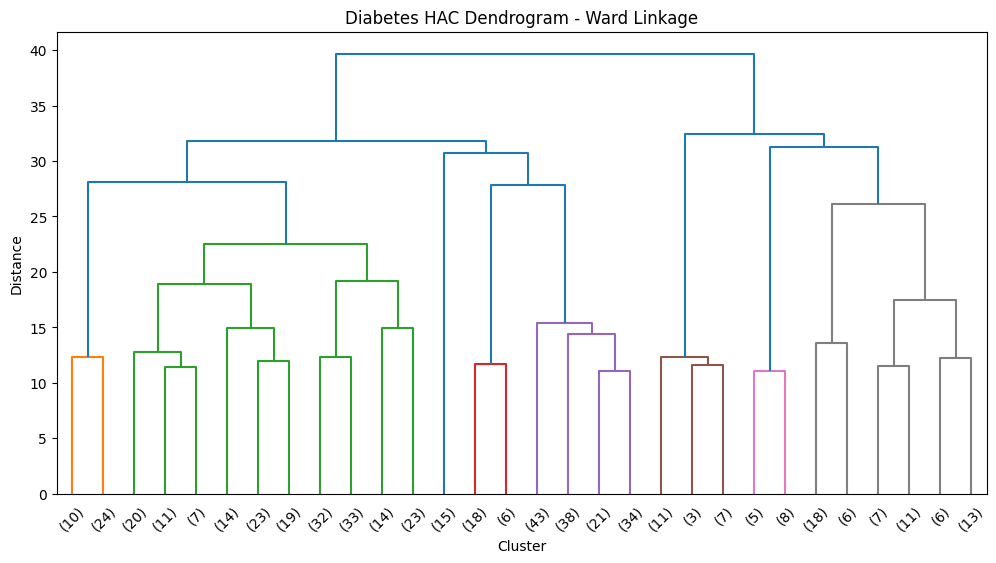

In [17]:
diabetes_dendrogram_sample = X_diabetes.sample(
    n=500,
    random_state=42
)

scaler_dendrogram = StandardScaler()
diabetes_dendrogram_scaled = scaler_dendrogram.fit_transform(
    diabetes_dendrogram_sample
)

diabetes_linkage_matrix = linkage(
    diabetes_dendrogram_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))
dendrogram(
    diabetes_linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.title("Diabetes HAC Dendrogram - Ward Linkage")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

### Diabetes Dendrogram

The dendrogram shows how observations are progressively merged under Ward linkage. The height of each merge represents the distance between the groups being combined. Larger vertical gaps suggest that relatively different clusters are being merged.

The diabetes dendrogram shows several larger merges near the top of the hierarchy, suggesting that a small number of broader clusters may provide a reasonable representation of the data. The dendrogram will be considered alongside silhouette scores rather than using the visual alone to select a final number of clusters.

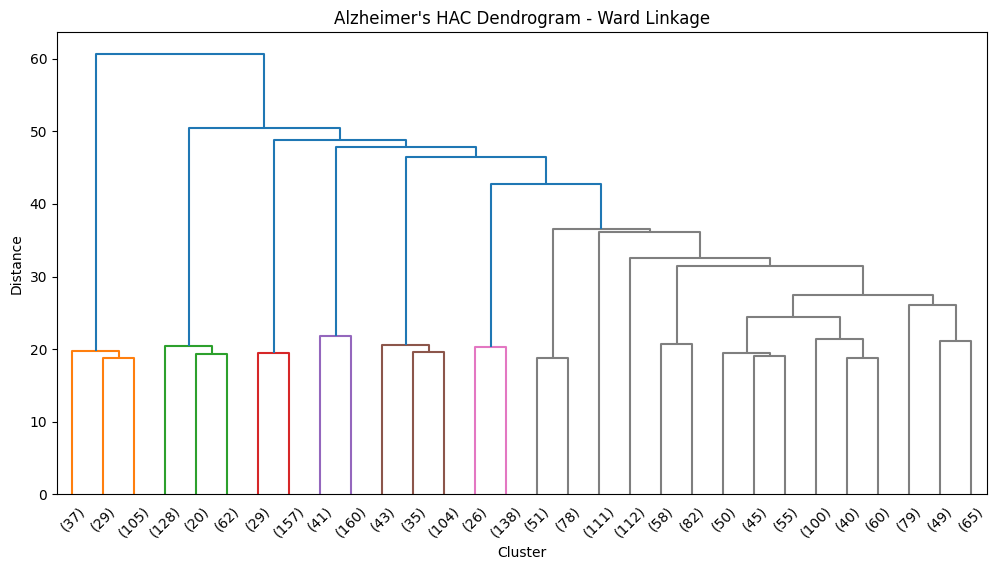

In [18]:
alzheimers_linkage_matrix = linkage(
    X_alzheimers_sample_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    alzheimers_linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.title("Alzheimer's HAC Dendrogram - Ward Linkage")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

### Alzheimer's Dendrogram

The Alzheimer's dendrogram shows a relatively large final merge at a distance of approximately 60, indicating separation between two broad groups at the highest level of the hierarchy. Below this point, several additional clusters merge at distances between approximately 43 and 50.

The dendrogram therefore suggests that a small number of broader clusters may be reasonable, but it does not provide one clearly defined cluster count. As with the diabetes data, the dendrogram will be considered together with silhouette scores when selecting the number of clusters rather than relying only on the visual pattern.

In [19]:
diabetes_hac_cluster_results = []

for n_clusters in range(2, 7):
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_diabetes_sample_scaled
    )

    score = silhouette_score(
        X_diabetes_sample_scaled,
        labels
    )

    diabetes_hac_cluster_results.append({
        "Clusters": n_clusters,
        "Silhouette Score": score
    })

diabetes_hac_cluster_results = pd.DataFrame(
    diabetes_hac_cluster_results
)

diabetes_hac_cluster_results

,Clusters,Silhouette Score
0,2,0.155342
1,3,0.165724
2,4,0.161676
3,5,0.172974
4,6,0.188223


### Diabetes HAC Cluster Count Comparison

Using Ward linkage, the diabetes silhouette score increased as the number of clusters rose from 2 to 6. The highest score among the tested values occurred with 6 clusters (0.1882), compared with 0.1553 for 2 clusters and 0.1657 for 3 clusters.

However, the differences between the scores were relatively small, so the results do not indicate one clearly dominant number of clusters. This is consistent with the dendrogram, which showed several possible higher-level divisions rather than one obvious cut point.

Among the tested values, 6 clusters provides the strongest silhouette score, but the relatively modest score still suggests limited separation between the groups.

In [20]:
alzheimers_hac_cluster_results = []

for n_clusters in range(2, 7):
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_alzheimers_sample_scaled
    )

    score = silhouette_score(
        X_alzheimers_sample_scaled,
        labels
    )

    alzheimers_hac_cluster_results.append({
        "Clusters": n_clusters,
        "Silhouette Score": score
    })

alzheimers_hac_cluster_results = pd.DataFrame(
    alzheimers_hac_cluster_results
)

alzheimers_hac_cluster_results

,Clusters,Silhouette Score
0,2,0.077522
1,3,0.042533
2,4,0.037488
3,5,0.038003
4,6,0.038096


### Alzheimer's HAC Cluster Count Comparison

Using Ward linkage, the Alzheimer's dataset produced its highest silhouette score with 2 clusters (0.0775). Increasing the number of clusters reduced the silhouette score substantially, with values near 0.04 for 3 through 6 clusters.

This result is consistent with the dendrogram, which showed a relatively large final merge separating two broad groups. Therefore, 2 clusters appears to be the most reasonable Ward-linkage solution among the tested values.

However, the silhouette score remains low, indicating that even the 2-cluster solution has weak separation. This supports the earlier DBSCAN result that the Alzheimer's feature space does not contain strongly defined natural clusters.

In [21]:
diabetes_hac_final = AgglomerativeClustering(
    n_clusters=6,
    linkage="ward"
)

diabetes_hac_labels = diabetes_hac_final.fit_predict(
    X_diabetes_sample_scaled
)

pd.Series(diabetes_hac_labels).value_counts().sort_index()

0    1236
1     187
2    2938
3     194
4     246
5     199
Name: count, dtype: int64

### Diabetes HAC Cluster Sizes

The final diabetes HAC model using Ward linkage and 6 clusters produced a more balanced structure than the single- and average-linkage solutions. The two largest clusters contained 2,938 and 1,236 patients, while the remaining clusters ranged from 187 to 246 patients.

Although the cluster sizes are still uneven, the solution avoids placing nearly all observations into a single group. Combined with the highest tested Ward silhouette score of 0.1882, this supports using 6 clusters as the final diabetes HAC solution.

In [22]:
alzheimers_hac_final = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

alzheimers_hac_labels = alzheimers_hac_final.fit_predict(
    X_alzheimers_sample_scaled
)

pd.Series(alzheimers_hac_labels).value_counts().sort_index()

0    1978
1     171
Name: count, dtype: int64

### Alzheimer's HAC Cluster Sizes

The final Alzheimer's HAC model using Ward linkage and 2 clusters produced a highly uneven split. One cluster contained 1,978 of the 2,149 patients, while the second contained only 171 patients.

Although the 2-cluster solution had the highest silhouette score among the tested Ward models, the silhouette score was still low (0.0775) and the cluster sizes were strongly imbalanced. This suggests that the Alzheimer's data contains only weak hierarchical separation, with most observations belonging to one broad group and a much smaller subgroup separating from it.

In [23]:
diabetes_hac_interpretation = pd.crosstab(
    diabetes_hac_labels,
    diabetes_sample_y,
    normalize="index"
).round(3)

diabetes_hac_interpretation

Diabetes_012,0.0,1.0,2.0
row_0,,,
0,0.748,0.028,0.224
1,0.973,0.016,0.011
2,0.884,0.014,0.102
3,0.675,0.010,0.314
4,0.907,0.020,0.073
5,0.834,0.015,0.151


### Diabetes HAC Diagnosis Comparison

The diabetes HAC clusters showed meaningful differences in diagnosis prevalence even though the diagnosis variable was not used to create the clusters.

Cluster 3 had the highest proportion of class 2 diabetes at 31.4%, followed by cluster 0 at 22.4%. In contrast, only 1.1% of patients in cluster 1 had class 2 diabetes, and cluster 2 had a lower rate of 10.2%.

However, every cluster was still dominated by patients without diabetes, and the clusters did not directly reproduce the three diagnosis categories. This suggests that HAC identified broader patient subgroups that are associated with different levels of diabetes prevalence rather than simply reconstructing the known outcome labels.

In [24]:
alzheimers_hac_interpretation = pd.crosstab(
    alzheimers_hac_labels,
    alzheimers_sample_y,
    normalize="index"
).round(3)

alzheimers_hac_interpretation

Diagnosis,0,1
row_0,,
0,0.647,0.353
1,0.637,0.363


### Alzheimer's HAC Diagnosis Comparison

The two Alzheimer's HAC clusters had nearly identical diagnosis distributions. Cluster 0 contained 35.3% diagnosed patients, while cluster 1 contained 36.3%.

This indicates that the two-cluster Ward solution does not meaningfully separate patients according to Alzheimer's diagnosis. Combined with the low silhouette score of 0.0775 and the highly uneven cluster sizes, the results suggest that the hierarchical structure identified in the Alzheimer's feature space has limited clinical separation with respect to the known diagnosis outcome.

In [25]:
hac_summary = pd.DataFrame({
    "Dataset": ["Diabetes", "Alzheimer's"],
    "Linkage": ["ward", "ward"],
    "Clusters": [6, 2],
    "Silhouette Score": [0.188223, 0.077522],
    "Largest Cluster": [2938, 1978],
    "Smallest Cluster": [187, 171]
})

hac_summary.round(4)

,Dataset,Linkage,Clusters,Silhouette Score,Largest Cluster,Smallest Cluster
0,Diabetes,ward,6,0.1882,2938,187
1,Alzheimer's,ward,2,0.0775,1978,171


### HAC Summary

Ward linkage produced the most balanced hierarchical clustering structure for both datasets compared with single and average linkage.

For diabetes, the final Ward model used 6 clusters and achieved a silhouette score of 0.1882. The largest cluster contained 2,938 patients and the smallest contained 187. The clusters also showed meaningful differences in diabetes prevalence, although they did not directly reproduce the known diagnosis categories.

For Alzheimer's disease, the final Ward model used 2 clusters with a silhouette score of 0.0775. The resulting split was highly uneven, with 1,978 patients in the larger cluster and 171 in the smaller cluster. The two clusters had nearly identical Alzheimer's diagnosis rates, suggesting limited clinical separation.

Overall, HAC identified more meaningful structure in the diabetes data than in the Alzheimer's data, but the relatively low silhouette scores indicate weak natural separation in both datasets.

## Conclusion

Week 11 applied DBSCAN and hierarchical agglomerative clustering to determine whether the diabetes and Alzheimer's datasets contain natural patient groupings. Because both methods rely on distances between observations, the features were standardized and the known diagnosis variables were excluded from the clustering process.

DBSCAN was highly sensitive to epsilon and MinPts. For diabetes, the selected configuration (epsilon = 3.25, MinPts = 10) identified 8 clusters, classified 19.18% of observations as noise, and produced a silhouette score of 0.1913. For Alzheimer's disease, the selected configuration (epsilon = 5.0, MinPts = 5) produced 3 clusters with 41.09% noise and a silhouette score of only 0.0004. The Alzheimer's parameter search was particularly sensitive, moving from nearly all observations being classified as noise at smaller epsilon values toward one dominant cluster as epsilon increased.

HAC also showed that clustering decisions can substantially affect the resulting groups. Single and average linkage sometimes produced higher silhouette scores, but they placed nearly all observations into one cluster. Ward linkage produced more balanced and interpretable groupings for both datasets. Using Ward linkage, the final diabetes solution used 6 clusters with a silhouette score of 0.1882, while the Alzheimer's solution used 2 clusters with a silhouette score of 0.0775. The dendrograms and cluster-count comparisons supported using a small number of broad groups, although neither dataset showed strong cluster separation.

The healthcare interpretation also differed across datasets. The diabetes HAC clusters showed meaningful differences in class 2 diabetes prevalence, ranging from 1.1% in one cluster to 31.4% in another. In contrast, the two Alzheimer's HAC clusters had nearly identical diagnosis rates of 35.3% and 36.3%. Therefore, the diabetes data appears to contain more meaningful unsupervised patient structure, while the Alzheimer's features do not separate naturally into groups that closely correspond with diagnosis.

Overall, neither DBSCAN nor HAC revealed strongly separated clusters, and the relatively low silhouette scores are an important limitation. However, the analysis demonstrated that parameter selection, linkage method, and cluster-count decisions can materially change unsupervised clustering results. It also showed that a mathematically identified cluster does not necessarily correspond to a clinically meaningful patient group.